# Grassland Quality — Initial Testing Notebook

This notebook is a first, runnable pass at the core ML pipeline for the grassland/pasture
quality project: pulling **AlphaEarth Foundations** satellite embeddings from Google Earth
Engine, pairing them with **MapBiomas** pasture labels, and training/fine-tuning a small
deep learning model (an LSTM head on top of the embeddings) to classify pasture quality.

**What this notebook does:**
1. Connects to Google Earth Engine
2. Defines a small test region in Goiás, Brazil (where published field-validated pasture
   data exists, useful for later benchmarking)
3. Pulls MapBiomas' *Pasture Vigor* map as a label source (high / medium / low vigor —
   a reasonable stand-in for "quality" while you build out the fuller pipeline)
4. Pulls multi-year AlphaEarth embedding sequences for sampled pasture points
5. Trains a small LSTM classifier on top of those embeddings (this is the "fine-tuning"
   step — AlphaEarth already did the heavy pretraining, so this notebook trains a
   lightweight task-specific head)
6. Evaluates on a held-out test set

**A note on reliability:** the exact internal structure (band names) of some MapBiomas
GEE assets can vary and occasionally changes between collection versions. The cells below
that touch these assets print out what they find *before* using it, and are written
defensively so you can quickly adjust a variable name if something doesn't match. This is
normal for a first working version — treat this as a strong starting scaffold, not a
finished pipeline.

**Before running:** you need a Google Cloud project with Earth Engine access enabled
(free for noncommercial/research use — register at
[code.earthengine.google.com/register](https://code.earthengine.google.com/register)
if you haven't already).

## 1. Setup

In [ ]:
# Most of these are preinstalled in Colab; -q keeps the output quiet and this is
# harmless to re-run even if already installed.
!pip install -q earthengine-api pandas numpy scikit-learn matplotlib


In [ ]:
import ee
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


In [ ]:
# Authenticate and initialize Earth Engine.
# Replace 'your-gcp-project-id' with your actual Google Cloud project ID that has
# Earth Engine enabled. Running this the first time will open a browser auth flow.

EE_PROJECT_ID = 'projetograssquality'  # <-- CHANGE THIS

ee.Authenticate()
ee.Initialize(project=EE_PROJECT_ID)
print("Earth Engine initialized.")


Earth Engine initialized.


## 2. Define a test region

We're using a bounding box around the Goiânia / Goiás region as a first test area — this
is where published LAPIG/MapBiomas field-validated pasture degradation data is
concentrated, which will be useful later for sanity-checking your model's outputs against
published numbers. Widen or move this box freely once the pipeline works end-to-end.

In [ ]:
# Rough bounding box in Goiás, Brazil (~65km x 65km around the Goiânia area).
# Adjust as needed — a smaller box keeps this first run fast.
aoi = ee.Geometry.Rectangle([-49.6, -16.9, -48.9, -16.3])

print("AOI area (km^2):", aoi.area().divide(1e6).getInfo())


AOI area (km^2): 4976.614815893002


## 3. Inspect the MapBiomas assets before using them

MapBiomas distributes some products as a single multi-band `ee.Image` (one band per year,
e.g. `pasture_vigor_2022`) and others as an `ee.ImageCollection` filtered by a `year`
property. This cell figures out which pattern applies here and prints what it finds —
**read the printed output before running the next cell**, since it determines which
loading path below you should use.

In [ ]:
PASTURE_VIGOR_ASSET = 'projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_pasture_vigor_v1'
LULC_ASSET = 'projects/mapbiomas-public/assets/brazil/lulc/v1'

YEAR = 2022  # reference year used to define labels; adjust based on data availability

# --- Pasture Vigor asset ---
try:
    pv_image = ee.Image(PASTURE_VIGOR_ASSET)
    pv_band_names = pv_image.bandNames().getInfo()
    print(f"Pasture Vigor loaded as a single Image with {len(pv_band_names)} bands.")
    print("Sample band names:", pv_band_names[:5], "...", pv_band_names[-5:])
    PV_IS_IMAGE = True
except Exception as e:
    print("Pasture Vigor did not load as a single Image, trying ImageCollection. Error:", e)
    pv_col = ee.ImageCollection(PASTURE_VIGOR_ASSET)
    first_props = pv_col.first().getInfo()
    print("Pasture Vigor loaded as an ImageCollection. First image info:", first_props)
    PV_IS_IMAGE = False

print()

# --- General Land Use / Land Cover asset (used to mask to pasture-only pixels) ---
lulc_col = ee.ImageCollection(LULC_ASSET)
lulc_year_image = lulc_col.filter(ee.Filter.eq('year', YEAR)).first()
lulc_band_names = lulc_year_image.bandNames().getInfo()
print(f"LULC ({YEAR}) band names:", lulc_band_names)


Pasture Vigor loaded as a single Image with 24 bands.
Sample band names: ['vigor_2000', 'vigor_2001', 'vigor_2002', 'vigor_2003', 'vigor_2004'] ... ['vigor_2019', 'vigor_2020', 'vigor_2021', 'vigor_2022', 'vigor_2023']

LULC (2022) band names: ['classification']


In [ ]:
# Pick the correct band for the reference YEAR based on what was printed above.
# This pattern works whether the band is named e.g. 'pasture_vigor_2022' or just 'classification'.

def find_year_band(band_names, year):
    matches = [b for b in band_names if str(year) in b]
    if matches:
        return matches[0]
    # Fall back to the only band if there's no year suffix (already filtered to one year)
    return band_names[0]

if PV_IS_IMAGE:
    vigor_band = find_year_band(pv_band_names, YEAR)
    vigor_layer = pv_image.select(vigor_band)
else:
    vigor_img = pv_col.filter(ee.Filter.eq('year', YEAR)).first()
    vigor_band = find_year_band(vigor_img.bandNames().getInfo(), YEAR)
    vigor_layer = vigor_img.select(vigor_band)

lulc_band = find_year_band(lulc_band_names, YEAR)
print("Using vigor band:", vigor_band)
print("Using LULC band:", lulc_band)

# MapBiomas class code for Pasture — verify against the current legend PDF at
# https://brasil.mapbiomas.org (legend codes can shift slightly between collections).
PASTURE_CLASS_CODE = 15

pasture_mask = lulc_year_image.select(lulc_band).eq(PASTURE_CLASS_CODE)
vigor_masked = vigor_layer.updateMask(pasture_mask).rename('vigor')


Using vigor band: vigor_2022
Using LULC band: classification


## 4. Sample labeled points

We take a stratified sample of pasture pixels so each vigor class is roughly balanced —
otherwise a class that covers most of the region would dominate training.

In [ ]:
POINTS_PER_CLASS = 100

sample_input = vigor_masked.addBands(ee.Image.pixelLonLat())

stratified_points = sample_input.stratifiedSample(
    numPoints=POINTS_PER_CLASS,
    classBand='vigor',
    region=aoi,
    scale=30,
    seed=SEED,
    geometries=True,
)

points_info = stratified_points.getInfo()['features']
print(f"Retrieved {len(points_info)} labeled points")

sample_points = []
for i, f in enumerate(points_info):
    coords = f['geometry']['coordinates']
    label = f['properties']['vigor']
    sample_points.append({'id': i, 'lon': coords[0], 'lat': coords[1], 'label': label})

points_df = pd.DataFrame(sample_points)
print(points_df['label'].value_counts())


Retrieved 300 labeled points
label
1    100
2    100
3    100
Name: count, dtype: int64


## 5. Pull multi-year AlphaEarth embeddings for each point

For each sampled point we build a short time series of AlphaEarth's 64-dimensional
embeddings — one vector per year. Points are re-uploaded as a fixed `FeatureCollection`
with a stable `id` so we can align each year's results back to the same point.

In [ ]:
def make_ee_points(df):
    features = [
        ee.Feature(ee.Geometry.Point([row.lon, row.lat]), {'id': int(row.id)})
        for row in df.itertuples()
    ]
    return ee.FeatureCollection(features)

points_fc = make_ee_points(points_df)

EMBED_YEARS = list(range(2018, 2024))  # AlphaEarth covers 2017 onward; adjust window as needed
embeddings_col = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')

embedding_records = {}  # id -> {year: [64 floats]}

for yr in EMBED_YEARS:
    start = ee.Date.fromYMD(yr, 1, 1)
    end = start.advance(1, 'year')
    yr_img = (
        embeddings_col
        .filter(ee.Filter.date(start, end))
        .filter(ee.Filter.bounds(aoi))
        .mosaic()
    )
    sampled = yr_img.sampleRegions(collection=points_fc, properties=['id'], scale=10)
    sampled_info = sampled.getInfo()['features']
    print(f"Year {yr}: retrieved {len(sampled_info)} embedding vectors")
    for feat in sampled_info:
        props = feat['properties']
        pid = props['id']
        vec = [props[f'A{str(b).zfill(2)}'] for b in range(64)]
        embedding_records.setdefault(pid, {})[yr] = vec


Year 2018: retrieved 300 embedding vectors
Year 2019: retrieved 300 embedding vectors
Year 2020: retrieved 300 embedding vectors
Year 2021: retrieved 300 embedding vectors
Year 2022: retrieved 300 embedding vectors
Year 2023: retrieved 300 embedding vectors


In [ ]:
complete_ids = [pid for pid, yrs in embedding_records.items() if all(y in yrs for y in EMBED_YEARS)]
print(f"{len(complete_ids)} / {len(points_df)} points have a complete {len(EMBED_YEARS)}-year embedding sequence")

X = np.array([[embedding_records[pid][yr] for yr in EMBED_YEARS] for pid in complete_ids], dtype=np.float32)
label_lookup = points_df.set_index('id')['label'].to_dict()
y_raw = np.array([label_lookup[pid] for pid in complete_ids])

print("X shape (samples, years, embedding_dim):", X.shape)
print("Raw label values:", np.unique(y_raw, return_counts=True))

# Remap labels to zero-indexed contiguous classes for PyTorch
unique_labels = sorted(np.unique(y_raw))
label_map = {v: i for i, v in enumerate(unique_labels)}
y = np.array([label_map[v] for v in y_raw])
NUM_CLASSES = len(unique_labels)
print("Class mapping (raw -> model index):", label_map)

# Cache to disk so you don't have to re-run the GEE extraction every time
np.savez('grassland_embeddings_dataset.npz', X=X, y=y, years=EMBED_YEARS, label_map=label_map)
print("Saved to grassland_embeddings_dataset.npz")

# To reload later instead of re-extracting from GEE:
#   data = np.load('grassland_embeddings_dataset.npz', allow_pickle=True)
#   X, y, EMBED_YEARS = data['X'], data['y'], list(data['years'])


300 / 300 points have a complete 6-year embedding sequence
X shape (samples, years, embedding_dim): (300, 6, 64)
Raw label values: (array([1, 2, 3]), array([100, 100, 100]))
Class mapping (raw -> model index): {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}
Saved to grassland_embeddings_dataset.npz


## 5b. (Optional) Synthetic fallback dataset

If you want to test the PyTorch pipeline below before your Earth Engine setup is fully
working — or you don't have EE access configured yet — set `USE_SYNTHETIC = True` and run
this cell. **Skip this if the real extraction above worked.**

In [ ]:
USE_SYNTHETIC = False  # set True to bypass the GEE extraction above

if USE_SYNTHETIC:
    n_samples, n_years, n_dims = 300, 6, 64
    rng = np.random.default_rng(SEED)
    X = rng.normal(0, 0.2, size=(n_samples, n_years, n_dims)).astype(np.float32)
    y = rng.integers(0, 3, size=n_samples)
    for i in range(n_samples):
        X[i, :, 0] += y[i] * 0.3  # inject a weak, learnable class-dependent signal
    NUM_CLASSES = 3
    print("Using SYNTHETIC dataset:", X.shape, y.shape)


## 6. PyTorch dataset and train / val / test split

In [ ]:
class GrasslandEmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


full_dataset = GrasslandEmbeddingDataset(X, y)
n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Train: {n_train}  Val: {n_val}  Test: {n_test}  (total: {n_total})")


Train: 210  Val: 45  Test: 45  (total: 300)


## 7. Model — a temporal "fine-tuning head" on top of AlphaEarth embeddings

AlphaEarth already did the expensive self-supervised pretraining across a huge
multi-sensor satellite archive. This model is the lightweight, task-specific piece you
actually train: an LSTM that reads a parcel's multi-year embedding trajectory and learns
to classify pasture quality/vigor from it.

In [ ]:
class GrasslandTemporalClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=64, num_layers=1, num_classes=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]  # (batch, hidden_dim) — final layer's hidden state
        return self.head(last_hidden)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GrasslandTemporalClassifier(input_dim=X.shape[-1], num_classes=NUM_CLASSES).to(device)
print(model)
print("Device:", device)


GrasslandTemporalClassifier(
  (lstm): LSTM(64, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)
Device: cuda


## 8. Train / fine-tune

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
N_EPOCHS = 30


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | train_loss {tr_loss:.4f} acc {tr_acc:.3f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.3f}")


Epoch  1 | train_loss 1.1026 acc 0.310 | val_loss 1.0961 acc 0.311
Epoch  5 | train_loss 1.0389 acc 0.548 | val_loss 0.9650 acc 0.644
Epoch 10 | train_loss 0.8058 acc 0.638 | val_loss 0.8011 acc 0.667
Epoch 15 | train_loss 0.7353 acc 0.662 | val_loss 0.7561 acc 0.689
Epoch 20 | train_loss 0.7544 acc 0.648 | val_loss 0.7051 acc 0.689
Epoch 25 | train_loss 0.7148 acc 0.686 | val_loss 0.7092 acc 0.733
Epoch 30 | train_loss 0.7246 acc 0.667 | val_loss 0.6926 acc 0.800


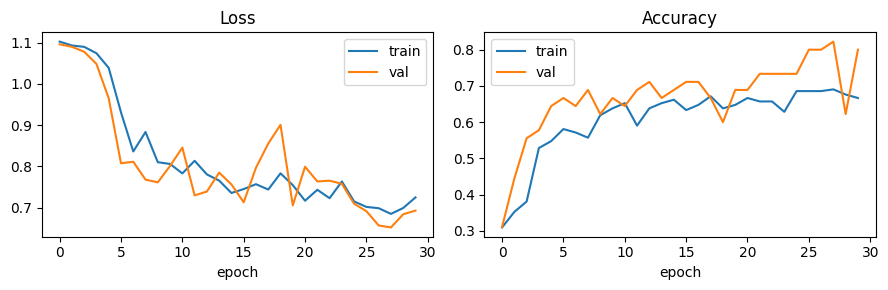

In [ ]:
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'], label='val')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.legend()

plt.tight_layout()
plt.show()


## 9. Test / evaluation

Test classification report:
              precision    recall  f1-score   support

     class_0       0.81      0.81      0.81        21
     class_1       0.55      0.50      0.52        12
     class_2       0.77      0.83      0.80        12

    accuracy                           0.73        45
   macro avg       0.71      0.71      0.71        45
weighted avg       0.73      0.73      0.73        45



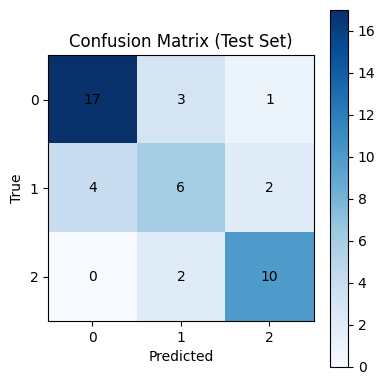

In [ ]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print("Test classification report:")
print(classification_report(
    all_true, all_preds,
    target_names=[f"class_{i}" for i in range(NUM_CLASSES)],
    zero_division=0,
))

cm = confusion_matrix(all_true, all_preds, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(range(NUM_CLASSES))
plt.yticks(range(NUM_CLASSES))
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()


## 10. Save the model

In [ ]:
torch.save(model.state_dict(), 'grassland_temporal_classifier.pt')
print("Model saved to grassland_temporal_classifier.pt")


Model saved to grassland_temporal_classifier.pt


## Next steps

This is a first working scaffold, not the finished project. Natural next steps, roughly
in order of value:

- **Swap in LAPIG's field-validated points** (or blend them with the MapBiomas pseudo-labels
  used here) for a higher-quality evaluation set — MapBiomas' vigor map is itself a model
  output, so treat it as a large, slightly noisy pretraining signal rather than ground truth.
- **Expand 3-class vigor into your actual "worth it" quadrant** by joining in the
  legal/environmental risk signals discussed earlier (CAR boundaries, PRODES/DETER
  deforestation flags, embargo status) rather than treating vegetation quality alone as the
  answer.
- **Move from points to parcels** once you're pulling real CAR property boundaries — replace
  point sampling with polygon-level aggregation (mean / percentile pooling of embeddings
  across all pixels inside each property) so predictions are made per-property, not per-pixel.
- **Try a Transformer encoder in place of the LSTM**, or add attention over the year
  dimension, once you have enough data to justify the extra capacity.
- **Consider fine-tuning Prithvi-EO-2.0 or Clay directly on imagery** (rather than using
  precomputed AlphaEarth embeddings) if you want the DL contribution to include learning
  from raw pixels, and if compute allows — LoRA/PEFT makes this feasible on modest hardware.
- Double-check the **MapBiomas class code for Pasture (assumed 15 here)** against the
  current legend published at brasil.mapbiomas.org before drawing conclusions from results.
